Files already downloaded and verified


CIFAR Layers:   0%|          | 0/1 [00:00<?, ?it/s]

train:   0%|          | 0/109 [00:00<?, ?it/s]

train:   0%|          | 0/109 [00:00<?, ?it/s]

train:   0%|          | 0/109 [00:00<?, ?it/s]

train:   0%|          | 0/109 [00:00<?, ?it/s]

train:   0%|          | 0/109 [00:00<?, ?it/s]

/home/users/par55/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


CSV → /home/users/par55/DiffusionDenoisingNotebooks/fast_layersweeps/fast_layersweep_cifar10_20250730_0335/results.csv
Plot → /home/users/par55/DiffusionDenoisingNotebooks/fast_layersweeps/fast_layersweep_cifar10_20250730_0335/layer_plot.png


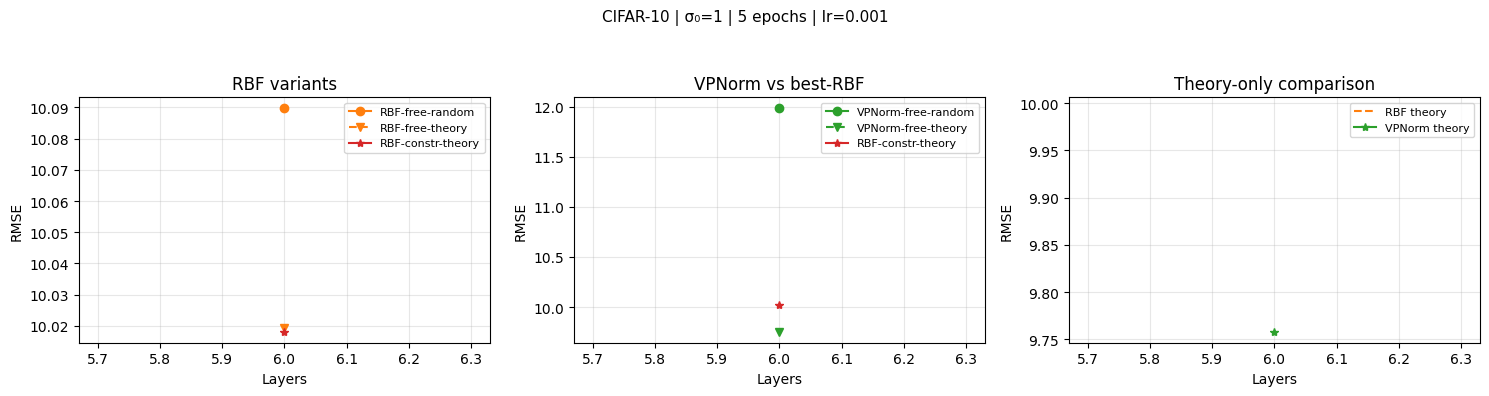

In [1]:
import math, time, csv, datetime as dt, random, re, importlib.util
from pathlib import Path
from typing import Dict

import torch, torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

ROOT = Path.cwd()     

#  sweep hyper-params 
LAYER_LIST   = [6]
EPOCHS_EACH  = 50
LR_INIT      = 1e-3
NOISE_STD    = 1 
BATCH_SZ     = 2048
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = ROOT / "fast_layersweeps"
OUT_DIR  = BASE_DIR / f"fast_layersweep_cifar10_{dt.datetime.now():%Y%m%d_%H%M}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

#  CIFAR-10 raw + unit tensors ─
to_flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
c10     = torchvision.datasets.CIFAR10("./data", train=True, download=True,
                                       transform=to_flat)
raw_all = torch.stack([x for x, _ in c10]).to(device)          # [50k,3072]
N=len(raw_all); n_train=int(0.9*N)
torch.manual_seed(0)
perm = torch.randperm(N, device=device)
train_idx, test_idx = perm[:n_train], perm[n_train:]



#  slice the data
train_raw = raw_all[train_idx]          # [45 000, 3072]
test_raw  = raw_all[test_idx]           # [ 5 000, 3072]

#  convert the old “global” index tensors to local indices
train_idx = torch.arange(train_raw.size(0), device=device)     # 0‥44 999
test_idx  = torch.arange(test_raw.size(0),  device=device)     # 0‥4 999


train_norms = train_raw.norm(dim=1, keepdim=True).clamp_min(1e-8)
test_norms  = test_raw.norm(dim=1, keepdim=True).clamp_min(1e-8)
train_unit  = train_raw / train_norms
test_unit   = test_raw  / test_norms

MEAN_NORM   = train_norms.mean().item()            # ≈ 27.4 on CIFAR-10
SIGMA0_UNIT = NOISE_STD / MEAN_NORM

#  import model + helpers 
src = ROOT / "DenoisingTesting.py"
spec = importlib.util.spec_from_file_location("denoise", src)
den  = importlib.util.module_from_spec(spec); spec.loader.exec_module(den)  # type: ignore

DenoiseTransformer   = den.DenoiseTransformer
theory_initialise    = den.theory_initialise
_enforce_constraint  = den._enforce_gamma_constraint

#  checkpoint helpers 
NAME_RE = re.compile(
    r"""ckpt_(?P<tag>.+?)_L(?P<L>\d+)_ep(?P<ep>\d+)_lr(?P<lr>[\d.]+)
        _sig(?P<sig>[\d.]+)\.pt$""", re.X)

def fname(tag:str,L:int)->str:
    return f"ckpt_{tag}_L{L}_ep{EPOCHS_EACH}_lr{LR_INIT:g}_sig{NOISE_STD:g}.pt"

def find_ckpt(tag:str,L:int)->Path|None:
    patt=f"ckpt_{tag}_L{L}_ep*_lr*_sig*.pt"
    for p in sorted(BASE_DIR.rglob(patt), key=lambda p:p.stat().st_mtime, reverse=True):
        m=NAME_RE.match(p.name)
        if not m: continue
        if int(m["ep"])!=EPOCHS_EACH: continue
        if abs(float(m["lr"])-LR_INIT)>1e-9: continue
        if abs(float(m["sig"])-NOISE_STD)>1e-9: continue
        return p
    return None

#  noise helper for VPNorm 
def add_unit_noise(raw:torch.Tensor, norms:torch.Tensor):
    eps=torch.randn_like(raw)
    return raw/norms + (NOISE_STD/norms)*eps, norms

#  quick trainer (γ constraint + VPNorm normalisation) 
def train_quick(model, *, kernel:str, constr:bool, steps:int):
    opt=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                         lr=LR_INIT, betas=(0.9,0.99))
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps, LR_INIT*1e-2)
    scaler=GradScaler()
    model.train()
    inner=tqdm(range(steps), desc="train", position=1, leave=False)
    for _ in inner:
        q=train_idx[torch.randint(0,n_train,(BATCH_SZ,),device=device)]
        if kernel=="vpnorm":
            cln_raw=train_raw[q]; norms=cln_raw.norm(dim=1,keepdim=True).clamp_min(1e-8)
            noisy_unit,_=add_unit_noise(cln_raw,norms)
            keys=train_unit; tgt_raw=cln_raw
        else:
            cln_raw=train_raw[q]
            noisy_raw=cln_raw + NOISE_STD*torch.randn_like(cln_raw)
            keys=train_raw; tgt_raw=cln_raw

        if constr: _enforce_constraint(model)

        with autocast():
            out_raw = (model(keys,noisy_unit)*norms if kernel=="vpnorm"
                       else model(keys,noisy_raw))
            loss=F.mse_loss(out_raw, tgt_raw)

        opt.zero_grad(); scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sch.step()
        inner.set_postfix(loss=f"{loss.item():.3e}")

@torch.no_grad()
def compute_rmse(model, *, kernel:str)->float:
    model.eval(); se,n=0.0,0
    for s in range(0,len(test_idx),BATCH_SZ):
        idx=test_idx[s:s+BATCH_SZ]
        if kernel=="vpnorm":
            cln_raw=test_raw[idx]; norms=test_norms[idx]
            noisy_unit,_=add_unit_noise(cln_raw,norms)
            out_raw=model(train_unit,noisy_unit)*norms
        else:
            cln_raw=test_raw[idx]
            noisy_raw=cln_raw+NOISE_STD*torch.randn_like(cln_raw)
            out_raw=model(train_raw,noisy_raw)
        se+=F.mse_loss(out_raw,cln_raw,reduction='sum').item(); n+=cln_raw.size(0)
    return math.sqrt(se/n)

#  sweep configuration 
cfgs=[("rbf","free","random"),
      ("rbf","free","theory"),
      ("rbf","constr","theory"),
      ("vpnorm","free","random"),
      ("vpnorm","free","theory")]
all_cols={f"{k}_{c}_{i}" for k,c,i in cfgs}|{"rbf_theory","vpnorm_theory"}

#  main sweep 
results: Dict[int,Dict[str,float]]={L:{} for L in LAYER_LIST}
t0=time.time()
outer=tqdm(LAYER_LIST, desc="CIFAR Layers", position=0)

for done,L in enumerate(outer,1):
    for kernel,mode,init in cfgs:
        constr=(mode=="constr")
        tag=f"{kernel}_{mode}_{init}"
        ckpt=find_ckpt(tag,L)
        if ckpt:
            state=torch.load(ckpt,map_location="cpu")
            mdl=DenoiseTransformer(L,kernel=kernel).to(device)
            mdl.load_state_dict(state["state_dict"] if isinstance(state,dict) else state, strict=False)
            print(f"✓ reuse {ckpt.relative_to(BASE_DIR)}")
        else:
            mdl=DenoiseTransformer(L,kernel=kernel).to(device)
            if constr:
                for lyr in mdl.layers: lyr.log_gamma.requires_grad_(False)
            if init=="theory":
                sigma0 = SIGMA0_UNIT if kernel=="vpnorm" else NOISE_STD
                theory_initialise(mdl, sigma0=sigma0, sigma_min=sigma0*1e-3)
            steps=int(EPOCHS_EACH*n_train/BATCH_SZ)
            train_quick(mdl,kernel=kernel,constr=constr,steps=steps)
            torch.save({"state_dict":mdl.state_dict(),
                        "meta":{"ep":EPOCHS_EACH,"lr":LR_INIT,"sig":NOISE_STD}},
                       OUT_DIR/fname(tag,L))

        results[L][tag]=compute_rmse(mdl,kernel=kernel)

    # free-theory baselines
    for k in ["rbf","vpnorm"]:
        key=f"{k}_theory"
        if key not in results[L]:
            m0=DenoiseTransformer(L,kernel=k).to(device)
            sigma0=SIGMA0_UNIT if k=="vpnorm" else NOISE_STD
            theory_initialise(m0, sigma0=sigma0, sigma_min=sigma0*1e-3)
            results[L][key]=compute_rmse(m0,kernel=k)

    elapsed=time.time()-t0
    outer.set_postfix(elapsed=f"{elapsed/60:.1f}m",
                      eta=f"{(len(LAYER_LIST)-done)*(elapsed/done)/60:.1f}m")
    outer.update(0)

outer.close()

#  save CSV 
csv_p=OUT_DIR/"results.csv"
with open(csv_p,"w",newline="") as f:
    hdr=["layers"]+sorted(all_cols); w=csv.writer(f); w.writerow(hdr)
    for L in LAYER_LIST:
        w.writerow([L]+[results[L].get(c,"") for c in hdr[1:]])
print("CSV →",csv_p)

#  plots 
x=np.array(LAYER_LIST,float)
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(x,[results[L]['rbf_free_random']  for L in LAYER_LIST],"C1o-",label='RBF-free-random')
plt.plot(x,[results[L]['rbf_free_theory']  for L in LAYER_LIST],"C1v--",label='RBF-free-theory')
plt.plot(x,[results[L]['rbf_constr_theory']for L in LAYER_LIST],"C3*-",label='RBF-constr-theory')
plt.title("RBF variants"); plt.xlabel("Layers"); plt.ylabel("RMSE")
plt.grid(alpha=0.3); plt.legend(fontsize=8)

plt.subplot(1,3,2)
plt.plot(x,[results[L]['vpnorm_free_random'] for L in LAYER_LIST],"C2o-",label='VPNorm-free-random')
plt.plot(x,[results[L]['vpnorm_free_theory'] for L in LAYER_LIST],"C2v--",label='VPNorm-free-theory')
plt.plot(x,[results[L]['rbf_constr_theory']  for L in LAYER_LIST],"C3*-",label='RBF-constr-theory')
plt.title("VPNorm vs best-RBF"); plt.xlabel("Layers"); plt.ylabel("RMSE")
plt.grid(alpha=0.3); plt.legend(fontsize=8)

plt.subplot(1,3,3)
plt.plot(x,[results[L]['rbf_theory']    for L in LAYER_LIST],"C1--",label='RBF theory')
plt.plot(x,[results[L]['vpnorm_theory'] for L in LAYER_LIST],"C2*-",label='VPNorm theory')
plt.title("Theory-only comparison"); plt.xlabel("Layers"); plt.ylabel("RMSE")
plt.grid(alpha=0.3); plt.legend(fontsize=8)

plt.suptitle(f"CIFAR-10 | σ₀={NOISE_STD} | {EPOCHS_EACH} epochs | lr={LR_INIT}", fontsize=11)
plt.tight_layout(rect=[0,0,1,0.93])
img_p=OUT_DIR/"layer_plot.png"; plt.savefig(img_p,dpi=200)
print("Plot →",img_p)
plt.show()


using fast_layersweep_cifar10_20250730_0335/ckpt_rbf_free_theory_L6_ep5_lr0.001_sig1.pt (ep5)
using fast_layersweep_cifar10_20250730_0335/ckpt_vpnorm_free_theory_L6_ep5_lr0.001_sig1.pt (ep5)
Plot → plots/CIFAR10_layer_progression_20250730_033817.png


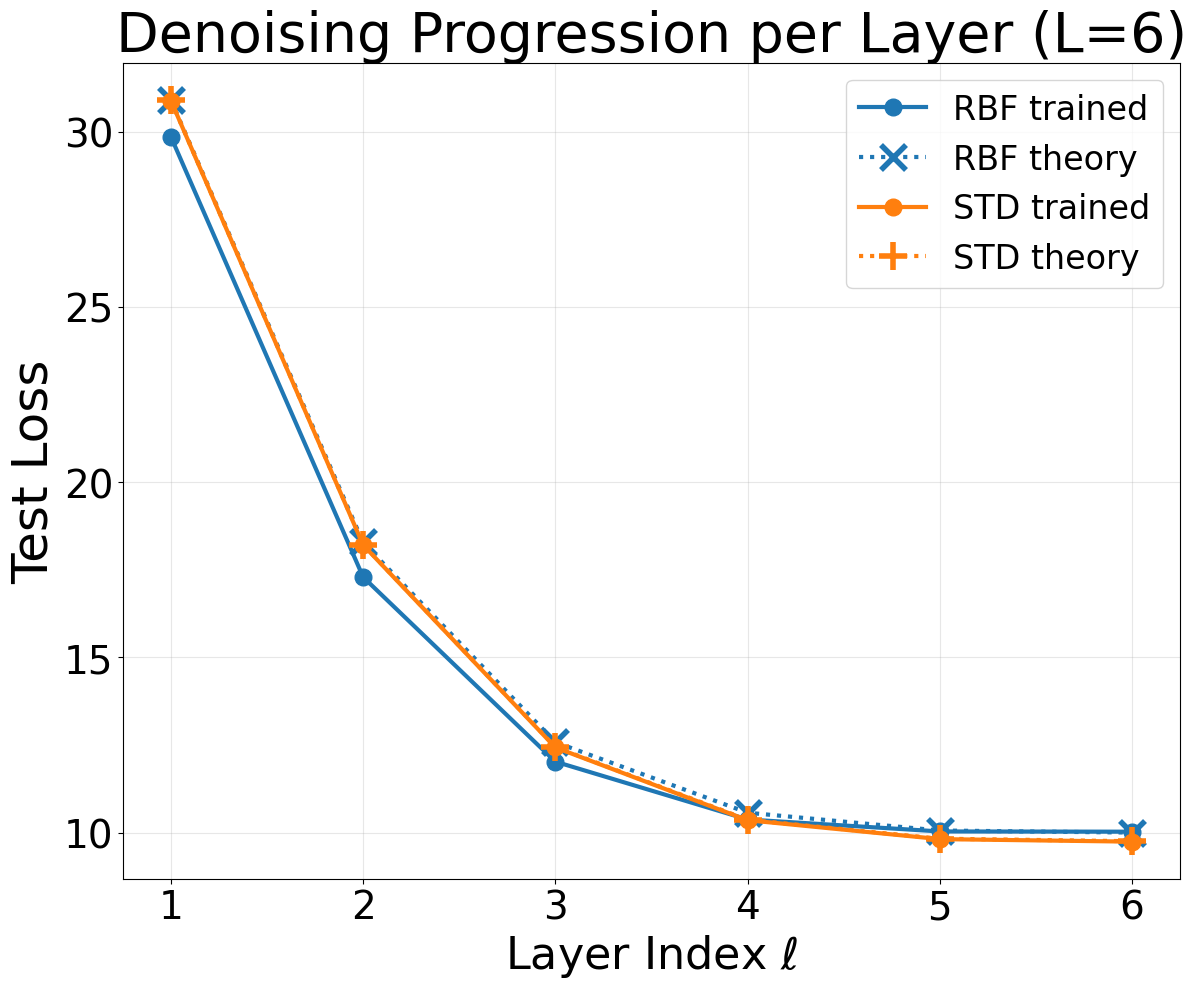

In [2]:

# [PROGRESSION PLOT CELL]  RMSE after every layer (CIFAR-10, L=10)
#
# • Looks for the highest-epoch checkpoint (or EXACT_EPOCH if set)
#   for each cfg in CFG_COMPARE.
# • Runs the test split through the model, recording RMSE after each
#   successive layer (k = 1…L).
# • Plots RBF vs STD (VPNorm) for the *trained* models plus their
#   closed-form theory counterparts.
#
# Assumes the  sweep cell above has finished and the variables
#   train_raw, train_unit, test_raw, test_norms, etc. are still in scope.

import datetime as dt, sys, re, math, csv
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import numpy as np

# ─── user-editable options 
DESIRED_LAYERS = 6        # we look for L == this value
EXACT_EPOCH    = 50      # set e.g. 150 to force ep150; else uses max ≥ MIN_EPOCHS
MIN_EPOCHS     = 50
CFG_COMPARE = [
    ("rbf",    "free",   "theory"),   # trained RBF
    ("vpnorm", "free",   "theory"),   # trained STD
]
# markers / colors for the 2 kernels
STYLE = {
    "rbf":    dict(color="C0", solid_marker="o", theory_marker="x"),
    "vpnorm": dict(color="C1", solid_marker="o", theory_marker="+"),
}

# ─── checkpoint search helper (reuse same regex) 
def best_ckpt(tag:str, L:int):
    patt = f"ckpt_{tag}_L{L}_ep*_lr*_sig*.pt"
    best_path, best_ep = None, -1
    for p in BASE_DIR.rglob(patt):
        m = NAME_RE.match(p.name)
        if not m: continue
        if abs(float(m["lr"])-LR_INIT)>1e-9 or abs(float(m["sig"])-NOISE_STD)>1e-9:
            continue
        ep = int(m["ep"])
        if EXACT_EPOCH is not None and ep != EXACT_EPOCH:
            continue
        if ep >= MIN_EPOCHS and ep > best_ep:
            best_path, best_ep = p, ep
    return best_path, best_ep if best_ep>=0 else None

# ─── RMSE after each layer 
@torch.no_grad()
def rmse_progression(model, *, kernel:str):
    L = len(model.layers)
    se = [0.0]*L
    n  = 0
    for s in range(0, len(test_idx), BATCH_SZ):
        idx = test_idx[s:s+BATCH_SZ]
        if kernel == "vpnorm":
            cln_raw = test_raw[idx]; norms = test_norms[idx]
            noisy_unit, _ = add_unit_noise(cln_raw, norms)
            q = noisy_unit.clone()
            keys = train_unit
        else:  # rbf
            cln_raw = test_raw[idx]
            noisy_raw = cln_raw + NOISE_STD * torch.randn_like(cln_raw)
            q = noisy_raw.clone()
            keys = train_raw

        q = q.to(device); keys = keys.to(device); tgt = cln_raw.to(device)
        for k, layer in enumerate(model.layers):
            q = layer(keys, q)
            if kernel == "vpnorm":           # convert back to raw scale
                q_out = q * norms.to(device)
            else:
                q_out = q
            se[k] += torch.nn.functional.mse_loss(q_out, tgt, reduction="sum").item()
        n += tgt.size(0)
    return [math.sqrt(s / n) for s in se]

# ─── gather curves for each cfg 
layer_ticks = np.arange(1, DESIRED_LAYERS+1)
out_curves  = {}
for kernel, mode, init in CFG_COMPARE:
    tag = f"{kernel}_{mode}_{init}"
    path, ep = best_ckpt(tag, DESIRED_LAYERS)
    if path is None:
        print(f"!! no checkpoint found for {tag}", file=sys.stderr); continue
    print(f"using {path.relative_to(BASE_DIR)} (ep{ep})")
    mdl = DenoiseTransformer(DESIRED_LAYERS, kernel=kernel).to(device)
    state = torch.load(path, map_location="cpu")
    mdl.load_state_dict(state["state_dict"] if isinstance(state,dict) else state,
                        strict=False)
    out_curves[(kernel, "trained")] = rmse_progression(mdl, kernel=kernel)

    # theory model
    m_th = DenoiseTransformer(DESIRED_LAYERS, kernel=kernel).to(device)
    sigma0 = SIGMA0_UNIT if kernel=="vpnorm" else NOISE_STD
    theory_initialise(m_th, sigma0=sigma0, sigma_min=sigma0*1e-3)
    out_curves[(kernel, "theory")] = rmse_progression(m_th, kernel=kernel)
# ─── plot (STD vs RBF) 
import datetime as dt
from pathlib import Path
import matplotlib.pyplot as plt

PLOTS_DIR = Path("./plots"); PLOTS_DIR.mkdir(exist_ok=True)
stamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

fig, ax = plt.subplots(figsize=(12, 10))
for kernel in ["rbf", "vpnorm"]:
    if (kernel, "trained") not in out_curves:
        continue

    style = STYLE[kernel]
    display_name = "STD" if kernel == "vpnorm" else kernel.upper()

    # trained curve
    ax.plot(
        layer_ticks,
        out_curves[(kernel, "trained")],
        color=style["color"],
        marker=style["solid_marker"],
        markersize=12,
        linewidth=3,
        label=f"{display_name} trained",
    )

    # theory curve
    ax.plot(
        layer_ticks,
        out_curves[(kernel, "theory")],
        color=style["color"],
        marker=style["theory_marker"],
        markersize=20 if kernel == "vpnorm" else 18,
        markeredgewidth=4,
        linewidth=3,
        linestyle=":",
        label=f"{display_name} theory",
    )

ax.set_xlabel(r"Layer Index $\ell$", fontsize=32)
ax.set_ylabel("Test Loss", fontsize=36)
ax.set_title("Denoising Progression per Layer (L=6)", fontsize=40)
ax.tick_params(axis="both", labelsize=28)
ax.grid(alpha=0.3)
ax.legend(fontsize=24, loc="best")

fig.tight_layout()
fname = PLOTS_DIR / f"CIFAR10_layer_progression_{stamp}.png"
fig.savefig(fname, dpi=200)
print("Plot →", fname)
plt.show()


In [8]:

# [RMSE & FID  – mean ± σ across N seeds, per layer, CIFAR‑10/100]
#
# • Trains RBF‑free‑theory and STD‑free‑theory N_RUNS  times
#   with different seeds.
# • Evaluates RMSE and FID on the held‑out test split after every
#   layer ℓ = 1…6 (keys remain the training set).
# • Uses a ThreadPoolExecutor with MAX_WORKERS = 3 so at most three
#   trainings run concurrently (threads are fine – PyTorch releases the
#   GIL during GPU work).
# • Outputs a tidy pandas DataFrame whose cells are formatted
#   “mean ± std‑dev”.


import torch, math, numpy as np, pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms as T
import datetime as dt, sys


N_RUNS       = 5         
MAX_WORKERS  = 3           # parallel threads
EPOCHS_EACH  = 75
L            = 6
BATCH_SZ_RMSE = 2048
BATCH_FID_R  = 512
BATCH_FID_F  = 512
NOISE_STD    = 1

# ─── dataset loader returning GPU tensors 
def load_flat(ds_name:str, *, seed:int):
    to_flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
    cls     = datasets.CIFAR10 if ds_name=="cifar10" else datasets.CIFAR100
    ds      = cls("./data", train=True, download=True, transform=to_flat)
    raw_all = torch.stack([x for x,_ in ds])  # CPU

    g = torch.Generator(device="cpu").manual_seed(seed)  # seed‑specific shuffle
    perm = torch.randperm(len(raw_all), generator=g)
    m = perm[: int(0.9*len(raw_all))]; n = perm[int(0.9*len(raw_all)):]
    tr = raw_all[m].cuda(); te = raw_all[n].cuda()
    tr_norm = tr.norm(dim=1, keepdim=True).clamp_min(1e-8)
    te_norm = te.norm(dim=1, keepdim=True).clamp_min(1e-8)
    tr_unit = tr / tr_norm
    return tr, tr_unit, te, te_norm

# ─── per‑layer RMSE & FID helpers (threads share everything) 
@torch.no_grad()
def rmse_progression(mdl, *, ker, tr_raw, tr_unit, te_raw, te_norm):
    mdl.eval(); se=[0.0]*L; n=0
    for s in range(0, te_raw.size(0), BATCH_SZ_RMSE):
        tgt = te_raw[s:s+BATCH_SZ_RMSE]
        norms=te_norm[s:s+BATCH_SZ_RMSE] if ker=="vpnorm" else None
        if ker=="vpnorm":
            noisy,_ = add_unit_noise(tgt,norms); q,keys=noisy, tr_unit
        else:
            q,keys=tgt+NOISE_STD*torch.randn_like(tgt), tr_raw
        for k,layer in enumerate(mdl.layers):
            q=layer(keys,q)
            out=q*norms if ker=="vpnorm" else q
            se[k]+=torch.nn.functional.mse_loss(out,tgt,reduction='sum').item()
        n+=tgt.size(0)
    return [math.sqrt(s/n) for s in se]

@torch.no_grad()
def fid_progression(mdl, *, ker, tr_raw, tr_unit, te_raw, te_norm):
    mdl.eval(); rng=torch.Generator(device='cuda').manual_seed(0); out=[]
    for cut in range(1,L+1):
        fid=FrechetInceptionDistance(feature=2048, normalize=True).cuda()
        for s in range(0, te_raw.size(0), BATCH_FID_R):
            fid.update(te_raw[s:s+BATCH_FID_R].reshape(-1,3,32,32).clamp(0,1),
                       real=True)
        produced=0
        while produced<te_raw.size(0):
            bs=min(BATCH_FID_F, te_raw.size(0)-produced)
            idx=torch.randint(0, te_raw.size(0), (bs,),
                              device=te_raw.device, generator=rng)
            cln=te_raw[idx]; norms=te_norm[idx] if ker=="vpnorm" else None
            if ker=="vpnorm":
                noisy,_=add_unit_noise(cln,norms); q,keys=noisy,tr_unit
            else:
                q,keys=cln+NOISE_STD*torch.randn_like(cln), tr_raw
            for lyr in mdl.layers[:cut]: q=lyr(keys,q)
            if ker=="vpnorm": q=q*norms
            fid.update(q.reshape(-1,3,32,32).clamp(0,1), real=False)
            produced+=bs
        out.append(fid.compute().item())
    return out

# ─── training wrapper 
def train_and_eval(seed:int, ds_name:str, ker:str):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_raw,tr_unit,te_raw,te_norm = load_flat(ds_name, seed=seed)

    mdl = DenoiseTransformer(L,kernel=ker).cuda()
    sigma0 = SIGMA0_UNIT if ker=="vpnorm" else NOISE_STD
    theory_initialise(mdl,sigma0=sigma0,sigma_min=sigma0*1e-3)
    steps=int(EPOCHS_EACH*tr_raw.size(0)/BATCH_SZ_RMSE)
    train_quick(mdl,kernel=ker,constr=False,steps=steps)

    rmse_vals = rmse_progression(mdl, ker=ker,
                                 tr_raw=tr_raw,tr_unit=tr_unit,
                                 te_raw=te_raw,te_norm=te_norm)
    fid_vals  = fid_progression(mdl, ker=ker,
                                 tr_raw=tr_raw,tr_unit=tr_unit,
                                 te_raw=te_raw,te_norm=te_norm)
    return dict(seed=seed,dataset=ds_name.upper(),kernel=ker,
                rmse=rmse_vals,fid=fid_vals)

# ─── schedule jobs 
jobs=[(s,d,k) for d in ("cifar10","cifar100") for k in ("rbf","vpnorm")
      for s in range(N_RUNS)]
print(f"Running {len(jobs)} trainings (max {MAX_WORKERS} parallel)…")

all_rows=[]
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futs=[pool.submit(train_and_eval,*j) for j in jobs]
    for fut in as_completed(futs):
        res=fut.result()
        for layer in range(L):
            all_rows.append(dict(Dataset=res["dataset"],
                                 Metric="RMSE",Layer=layer+1,
                                 Variant=f"{'RBF' if res['kernel']=='rbf' else 'STD'} trained",
                                 Value=res["rmse"][layer]))
            all_rows.append(dict(Dataset=res["dataset"],
                                 Metric="FID",Layer=layer+1,
                                 Variant=f"{'RBF' if res['kernel']=='rbf' else 'STD'} trained",
                                 Value=res["fid"][layer]))
        print(f"✓ seed {res['seed']:02d} {res['dataset']} {res['kernel']} done")

# ---- aggregate mean ± σ 
df=pd.DataFrame(all_rows)
def fmt(series): return f"{series.mean():.4f} ± {series.std(ddof=1):.4f}"
table=(df.pivot_table(index=["Dataset","Metric","Layer"],
                      columns="Variant",values="Value",aggfunc=fmt)
         .reindex(["CIFAR10","CIFAR100"],level=0))
print("\nMean ± σ across",N_RUNS,"seeds (test split)")
display(table)


Running 20 trainings (max 3 parallel)…
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


train:   0%|          | 0/1647 [00:00<?, ?it/s]

train:   0%|          | 0/1647 [00:00<?, ?it/s]

train:   0%|          | 0/1647 [00:00<?, ?it/s]

✓ seed 02 CIFAR10 rbf done
Files already downloaded and verified


...

train:   0%|          | 0/1647 [00:00<?, ?it/s]

✓ seed 01 CIFAR100 vpnorm done
Files already downloaded and verified


train:   0%|          | 0/1647 [00:00<?, ?it/s]

✓ seed 03 CIFAR100 vpnorm done
✓ seed 02 CIFAR100 vpnorm done
✓ seed 04 CIFAR100 vpnorm done

Mean ± σ across 5 seeds (test split)


Variant                      RBF trained        STD trained
Dataset  Metric Layer                                      
CIFAR10  FID    1      343.9707 ± 1.3566  403.5518 ± 1.0484
                2      195.9682 ± 1.8559  320.8687 ± 1.3545
                3       98.0339 ± 1.0008  233.2732 ± 0.9515
                4       43.2613 ± 0.7732  163.5197 ± 1.6950
                5       21.8660 ± 0.5442  114.0156 ± 1.5620
                6       19.3063 ± 0.1546   78.5132 ± 0.6098
         RMSE   1       20.0300 ± 0.0997   30.8837 ± 0.0031
                2       10.9777 ± 0.0206   18.2155 ± 0.0091
                3        9.9822 ± 0.0233   12.4484 ± 0.0185
                4       10.0486 ± 0.0253   10.3784 ± 0.0260
                5       10.1176 ± 0.0257    9.8413 ± 0.0297
                6       10.1461 ± 0.0257    9.7701 ± 0.0311
CIFAR100 FID    1      324.5138 ± 2.1517  391.3787 ± 1.4223
                2      179.1507 ± 1.4386  300.9534 ± 1.4732
                3       95.0732 ± 0.9088  212.4006 ± 1.5248
                4       46.2433 ± 1.0586  150.6603 ± 1.3517
                5       25.2476 ± 0.6853  108.6051 ± 0.9484
                6       22.8847 ± 0.3831   78.5473 ± 1.3952
         RMSE   1       20.0508 ± 0.0765   30.8714 ± 0.0073
                2       10.9268 ± 0.0424   18.1737 ± 0.0124
                3        9.9062 ± 0.0416   12.3672 ± 0.0233
                4        9.9679 ± 0.0432   10.2665 ± 0.0332
                5       10.0360 ± 0.0440    9.7145 ± 0.0385
                6       10.0642 ± 0.0443    9.6374 ± 0.0408